                                         Car Price Data Cleaning & Exploratory Data Analysis (EDA)

In [61]:
 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

%matplotlib inline 

sns.set_style('whitegrid')

In [62]:
data=pd.read_csv(r"C:\Users\sumit_86ovcyw\Downloads\car_price_prediction_.csv")


In [63]:
# data shape 

data.shape

(2500, 10)

In [64]:
# data 

data.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [65]:
# data information 

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [41]:
# data statistical information

data.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [42]:
# object column describtion 

data.describe(include=['object'])

,Brand,Fuel Type,Transmission,Condition,Model
count,2500,2500,2500,2500,2500
unique,7,4,2,3,28
top,Toyota,Diesel,Manual,Used,Fiesta
freq,374,655,1308,855,103



                                                           Data cleaning 
                                                           

In [43]:
data.isnull()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
2495,False,False,False,False,False,False,False,False,False,False
2496,False,False,False,False,False,False,False,False,False,False
2497,False,False,False,False,False,False,False,False,False,False
2498,False,False,False,False,False,False,False,False,False,False


In [44]:
# data null values 

data.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

CHECK FOR DUPLICATES

In [45]:
# Numbers of duplicate rows 

data.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool

In [46]:
# Sum of Duplicates 

data.duplicated().sum()

np.int64(0)

In [47]:
# check for the data inconsistencies

categorical_colums=['Brand','Fuel Type','Transmission','Condition','Model']
for col in categorical_colums:
    print(f" unique vaule in  {col}: { data[col].unique()}")
 

 unique vaule in  Brand: ['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']
 unique vaule in  Fuel Type: ['Petrol' 'Electric' 'Diesel' 'Hybrid']
 unique vaule in  Transmission: ['Manual' 'Automatic']
 unique vaule in  Condition: ['New' 'Used' 'Like New']
 unique vaule in  Model: ['Model X' '5 Series' 'A4' 'Model Y' 'Mustang' 'Q7' 'Q5' 'Civic'
 'Explorer' 'Model 3' 'Fiesta' 'X3' 'GLA' 'A3' 'X5' 'C-Class' 'E-Class'
 'CR-V' 'Camry' 'Accord' 'GLC' 'Corolla' 'Fit' 'Model S' 'Prius'
 '3 Series' 'RAV4' 'Focus']


In [48]:
# Numerical data 

print("Years range:", data['Year'].min(),"-", data["Year"].max())

Years range: 2000 - 2023


In [49]:
# Price Range

print("Price range: From", data['Price'].min(),"To", data["Price"].max())


Price range: From 5011.27 To 99982.59


In [50]:
#Engine Capacity Range

print("Engine Capacity Range: From", data['Engine Size'].min(),"To", data["Engine Size"].max() , "L")

Engine Capacity Range: From 1.0 To 6.0 L


EXPLORATORY DATA ANALYSIS (EDA) AND VISUALIZATION

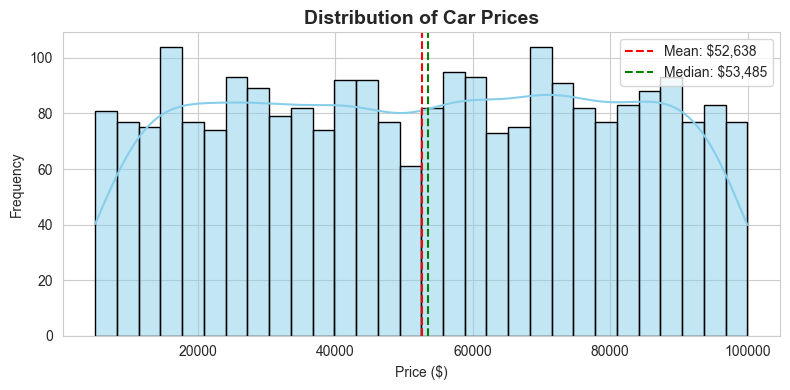

In [51]:
# Distribution of car prices

plt.figure(figsize=(8, 4))
sns.histplot(data['Price'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Car Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
# Add statistics to title or annotation

mean_price = data['Price'].mean()
median_price = data['Price'].median()
plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='green', linestyle='--', label=f'Median: ${median_price:,.0f}')
plt.legend()
plt.tight_layout()
plt.savefig("Distribution of Car Prices.png", dpi=300)
plt.show()


In [52]:
plt.savefig("Distribution of Car Prices.png", dpi=300)



<Figure size 640x480 with 0 Axes>

C:\Users\sumit_86ovcyw\AppData\Local\Temp\ipykernel_16316\663456121.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')


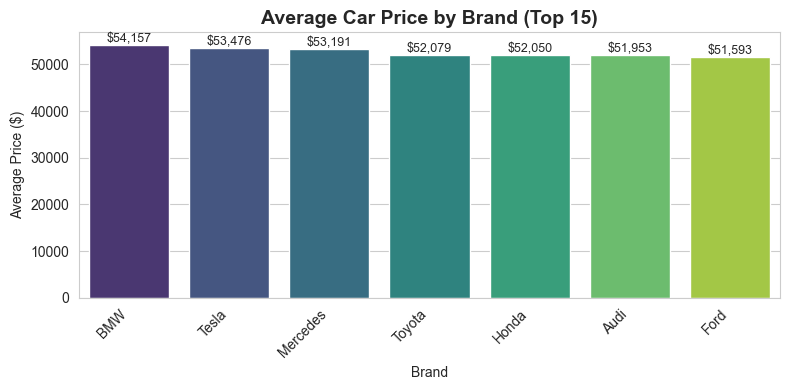

In [53]:
# 2. Average price by Brand (improved)
plt.figure(figsize=(8, 4))
avg_price = data.groupby('Brand')['Price'].mean().sort_values(ascending=False)

# Show top 15 brands to avoid overcrowding
top_brands = avg_price.head(15)
sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Average Car Price by Brand (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Average Price ($)')

# Add value labels on bars
for i, v in enumerate(top_brands.values):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("Average Car Price by Brand (Top 15).png", dpi=300)

plt.show()



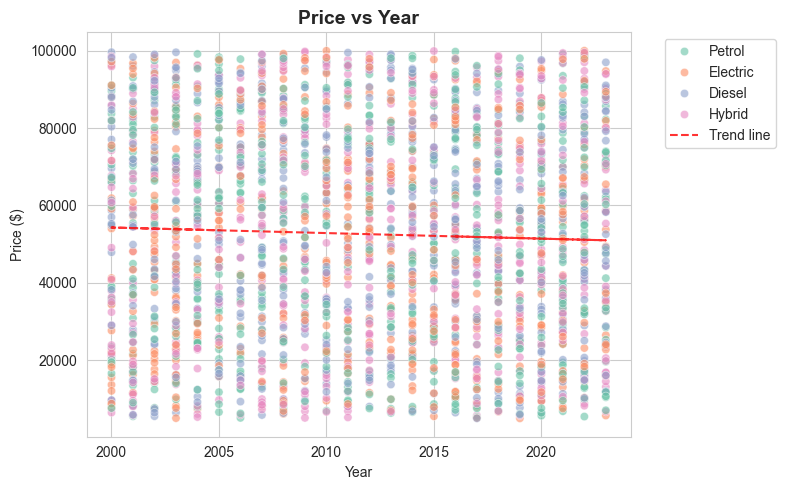

In [54]:
# 3. Price vs Year (improved)
plt.figure(figsize=(8, 5))
scatter = sns.scatterplot(x='Year', y='Price', data=data, alpha=0.6, hue='Fuel Type', palette='Set2')
plt.title('Price vs Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price ($)')

# Add trend line
z = np.polyfit(data['Year'], data['Price'], 1)
p = np.poly1d(z)
plt.plot(data['Year'], p(data['Year']), "r--", alpha=0.8, label='Trend line')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("Price vs Year.png", dpi=300)
plt.show()

C:\Users\sumit_86ovcyw\AppData\Local\Temp\ipykernel_16316\284663122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel Type', y='Price', data=data, palette='Pastel1')


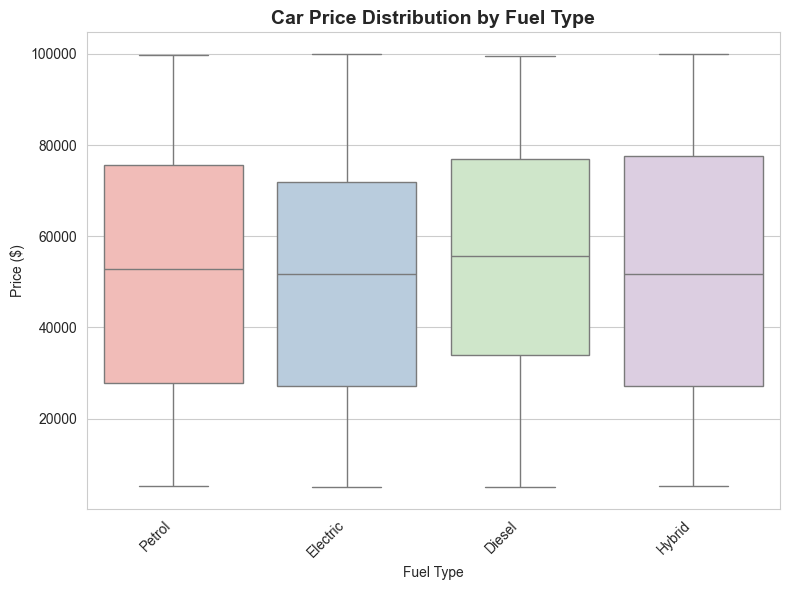

In [55]:
# 4. Price by Fuel Type (improved)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Fuel Type', y='Price', data=data, palette='Pastel1')
plt.title('Car Price Distribution by Fuel Type', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')

# Rotate x-labels if they're long
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Car Price Distribution by Fuel Type.png", dpi=300)
plt.show()

 

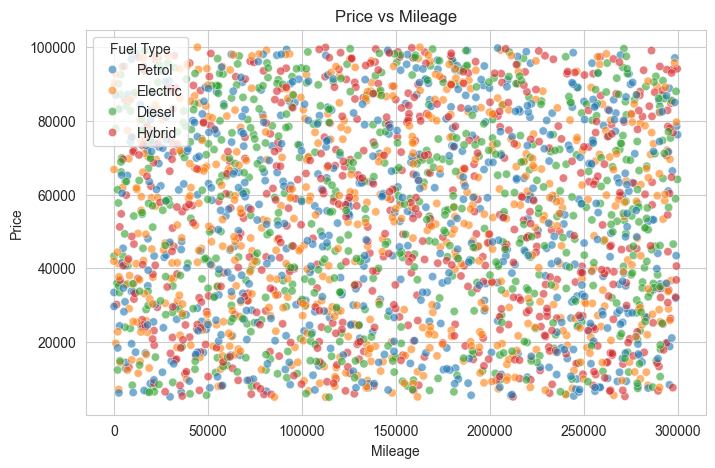

In [56]:
# 2. Mileage vs Price correlation
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', data=data, alpha=0.6, hue='Fuel Type')
plt.title('Price vs Mileage')
plt.savefig("Price vs Mileage.png", dpi=300)
plt.show()

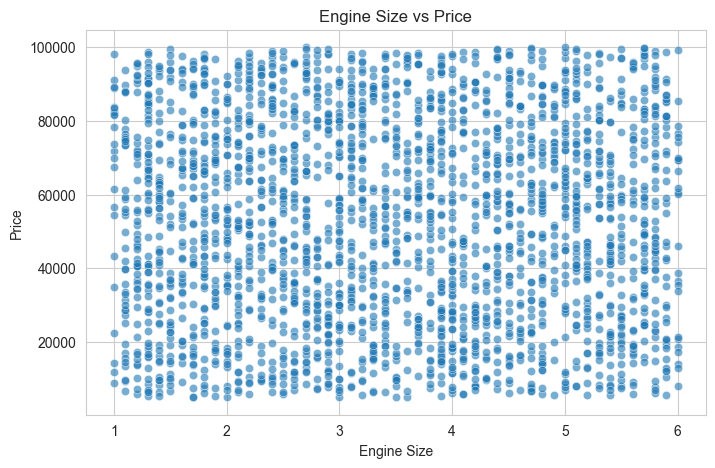

In [57]:
# 3. Engine Size vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='Engine Size', y='Price', data=data, alpha=0.6)
plt.title('Engine Size vs Price')
plt.savefig("Engine Size vs Price.png", dpi=300)
plt.show()


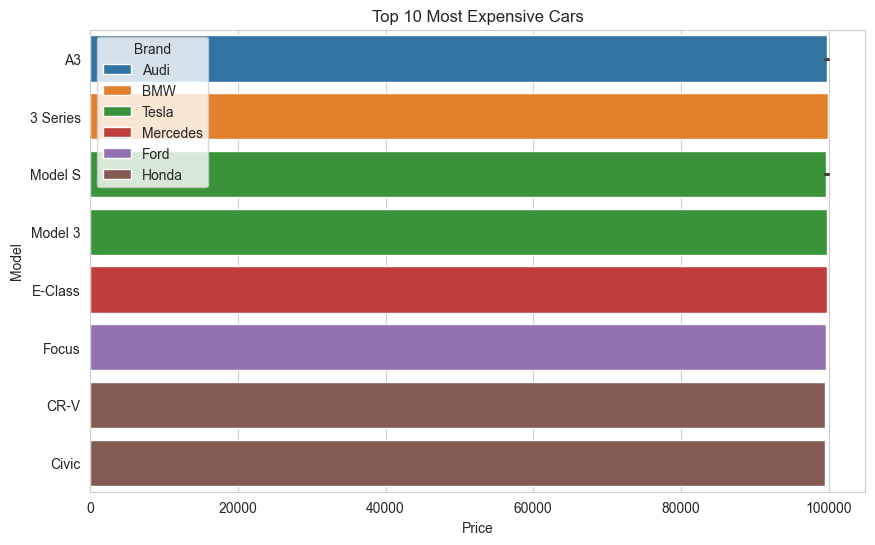

In [58]:
# 6. Top 10 Most Expensive Cars
plt.figure(figsize=(10,6))
top_expensive = data.nlargest(10, 'Price')[['Brand', 'Model', 'Price']]
sns.barplot(x='Price', y='Model', data=top_expensive, hue='Brand', dodge=False)
plt.title('Top 10 Most Expensive Cars')
plt.savefig("Top 10 Most Expensive Cars.png", dpi=300)
plt.show()


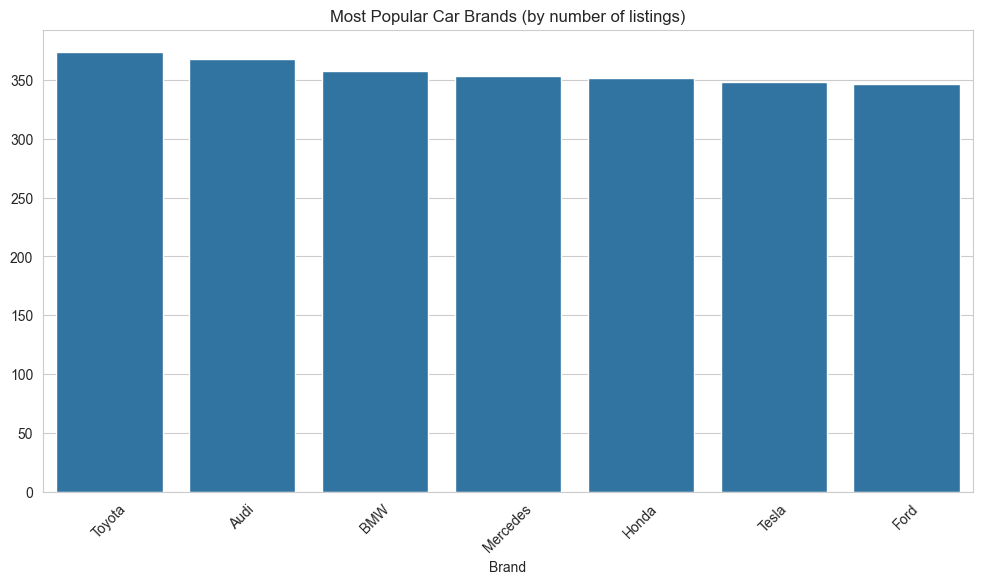

In [59]:
# 7. Brand popularity (count of listings)
plt.figure(figsize=(12,6))
brand_counts = data['Brand'].value_counts().head(15)
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.xticks(rotation=45)
plt.title('Most Popular Car Brands (by number of listings)')
plt.savefig("Most Popular Car Brands (by number of listings).png", dpi=300)
 
plt.show()


1. WHERE DO MOST CAR PRICES FALL?


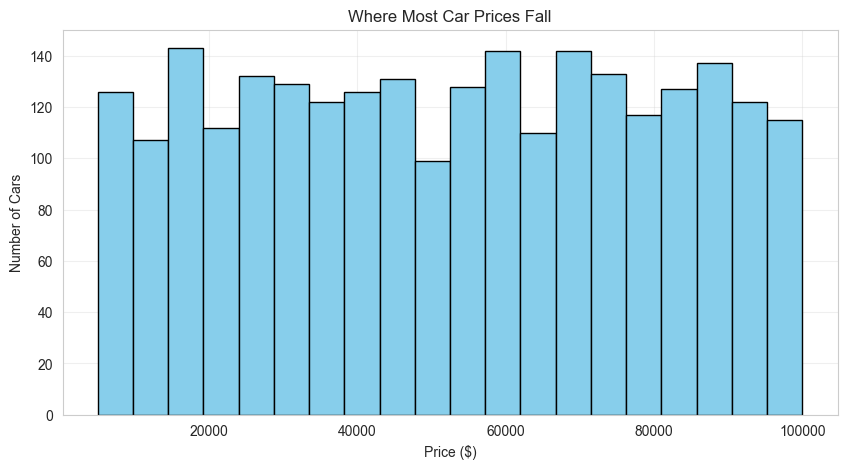

• This shows how many cars are available at different price points
• Most cars cluster in the lower price ranges
• Only a few cars are very expensive


In [60]:
# Plot 1: Where do most car prices fall?
print("\n1. WHERE DO MOST CAR PRICES FALL?")
plt.figure(figsize=(10, 5))
plt.hist(data['Price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Where Most Car Prices Fall')
plt.xlabel('Price ($)')
plt.ylabel('Number of Cars')
plt.grid(True, alpha=0.3)
plt.savefig("Where Most Car Prices Fall.png", dpi=300)
plt.show()

print("• This shows how many cars are available at different price points")
print("• Most cars cluster in the lower price ranges")
print("• Only a few cars are very expensive")